<a href="https://colab.research.google.com/github/Kri520/Heavy-metal-Pollution/blob/main/HPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [73]:
# Run once if necessary
# !pip install xgboost

from xgboost import XGBRegressor

In [74]:
metal_df = pd.read_excel(
    "/content/Heavy_Metal_Concentrations.xlsx", header=1
)

index_df = pd.read_excel(
    "/content/Pollution_Indices.xls", header=1
)

print(metal_df.head())
print(index_df.head())

  Site  Year   Month   Zn   Cd    Pb  Cu   Ni   Mn   As   Cr
0   S1  2018  winter  5.40  1.0  1.0  6.3   3  5.3  5.0  1.0
1   S1  2018  spring  4.80  1.0  1.2  5.4   3  4.7  5.0  1.0
2   S1  2018  summer  5.90  1.0  1.0  4.8   3  1.0  5.0  1.0
3   S1  2018  autumn  4.05  1.0  1.0  5.3   6  1.0  5.0  1.0
4   S1  2019  winter  4.00  1.0  1.4  8.6   3  2.3  5.0  1.0
  Site  Year   Month   Zn   Cd    Pb  Cu   Ni   Mn   As  ...      HEI  \
0   S1  2018  winter  5.40  1.0  1.0  6.3   3  5.3  5.0  ...  3.20308   
1   S1  2018  spring  4.80  1.0  1.2  5.4   3  4.7  5.0  ...  3.19296   
2   S1  2018  summer  5.90  1.0  1.0  4.8   3  1.0  5.0  ...  3.08718   
3   S1  2018  autumn  4.05  1.0  1.0  5.3   6  1.0  5.0  ...  3.24681   
4   S1  2019  winter  4.00  1.0  1.4  8.6   3  2.3  5.0  ...  3.22880   

     Zn .8  Cd .8  Pb.8  Cu .8  Ni.8   Mn.8  As.8  Cr.8     DC  
0 -0.99892   -0.8 -0.90 -0.874 -0.85 -0.894  -0.5 -0.98 -5.798  
1 -0.99904   -0.8 -0.88 -0.892 -0.85 -0.906  -0.5 -0.98 -5.808  


In [75]:
print("Metal dataset shape:")
print(metal_df.shape)

print("\nIndex dataset shape:")
print(index_df.shape)

Metal dataset shape:
(40, 11)

Index dataset shape:
(40, 78)


In [76]:
print(metal_df.columns)
print(index_df.columns)

Index(['Site', 'Year', 'Month', 'Zn ', 'Cd ', 'Pb', 'Cu ', 'Ni', 'Mn', 'As',
       'Cr'],
      dtype='object')
Index(['Site', 'Year', 'Month', 'Zn ', 'Cd ', 'Pb', 'Cu ', 'Ni', 'Mn', 'As',
       'Cr', 'Zn .1', 'Cd .1', 'Pb.1', 'Cu .1', 'Ni.1', 'Mn.1', 'As.1', 'Cr.1',
       'Zn .2', 'Cd .2', 'Pb.2', 'Cu .2', 'Ni.2', 'Mn.2', 'As.2', 'Cr.2',
       'Zn .3', 'Cd .3', 'Pb.3', 'Cu .3', 'Ni.3', 'Mn.3', 'As.3', 'Cr.3',
       'Zn .4', 'Cd .4', 'Pb.4', 'Cu .4', 'Ni.4', 'Mn.4', 'As.4', 'Cr.4',
       'Zn .5', 'Cd .5', 'Pb.5', 'Cu .5', 'Ni.5', 'Mn.5', 'As.5', 'Cr.5',
       'Zn .6', 'Cd .6', 'Pb.6', 'Cu .6', 'Ni.6', 'Mn.6', 'As.6', 'Cr.6',
       'HPI', 'Zn .7', 'Cd .7', 'Pb.7', 'Cu .7', 'Ni.7', 'Mn.7', 'As.7',
       'Cr.7', 'HEI', 'Zn .8', 'Cd .8', 'Pb.8', 'Cu .8', 'Ni.8', 'Mn.8',
       'As.8', 'Cr.8', 'DC'],
      dtype='object')


In [77]:
metal_df.columns = (
    metal_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

index_df.columns = (
    index_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(metal_df.columns)
print(index_df.columns)

Index(['Site', 'Year', 'Month', 'Zn', 'Cd', 'Pb', 'Cu', 'Ni', 'Mn', 'As',
       'Cr'],
      dtype='object')
Index(['Site', 'Year', 'Month', 'Zn', 'Cd', 'Pb', 'Cu', 'Ni', 'Mn', 'As', 'Cr',
       'Zn_.1', 'Cd_.1', 'Pb.1', 'Cu_.1', 'Ni.1', 'Mn.1', 'As.1', 'Cr.1',
       'Zn_.2', 'Cd_.2', 'Pb.2', 'Cu_.2', 'Ni.2', 'Mn.2', 'As.2', 'Cr.2',
       'Zn_.3', 'Cd_.3', 'Pb.3', 'Cu_.3', 'Ni.3', 'Mn.3', 'As.3', 'Cr.3',
       'Zn_.4', 'Cd_.4', 'Pb.4', 'Cu_.4', 'Ni.4', 'Mn.4', 'As.4', 'Cr.4',
       'Zn_.5', 'Cd_.5', 'Pb.5', 'Cu_.5', 'Ni.5', 'Mn.5', 'As.5', 'Cr.5',
       'Zn_.6', 'Cd_.6', 'Pb.6', 'Cu_.6', 'Ni.6', 'Mn.6', 'As.6', 'Cr.6',
       'HPI', 'Zn_.7', 'Cd_.7', 'Pb.7', 'Cu_.7', 'Ni.7', 'Mn.7', 'As.7',
       'Cr.7', 'HEI', 'Zn_.8', 'Cd_.8', 'Pb.8', 'Cu_.8', 'Ni.8', 'Mn.8',
       'As.8', 'Cr.8', 'DC'],
      dtype='object')


In [78]:
# Create a mapping for seasons to month numbers
season_to_month = {
    'winter': '01',
    'spring': '04',
    'summer': '07',
    'autumn': '10'
}

# Map the 'Month' column to numeric months and create the 'Date' column
metal_df['Numeric_Month'] = metal_df['Month'].map(season_to_month)
index_df['Numeric_Month'] = index_df['Month'].map(season_to_month)

metal_df["Date"] = pd.to_datetime(
    metal_df["Year"].astype(str) + '-' + metal_df["Numeric_Month"] + '-01',
    format='%Y-%m-%d',
    errors='coerce'
)

index_df["Date"] = pd.to_datetime(
    index_df["Year"].astype(str) + '-' + index_df["Numeric_Month"] + '-01',
    format='%Y-%m-%d',
    errors='coerce'
)

# Drop the temporary 'Numeric_Month' column
metal_df = metal_df.drop(columns=['Numeric_Month'])
index_df = index_df.drop(columns=['Numeric_Month'])

print(metal_df[['Year', 'Month', 'Date']].head())
print(index_df[['Year', 'Month', 'Date']].head())

   Year   Month       Date
0  2018  winter 2018-01-01
1  2018  spring 2018-04-01
2  2018  summer 2018-07-01
3  2018  autumn 2018-10-01
4  2019  winter 2019-01-01
   Year   Month       Date
0  2018  winter 2018-01-01
1  2018  spring 2018-04-01
2  2018  summer 2018-07-01
3  2018  autumn 2018-10-01
4  2019  winter 2019-01-01


In [79]:
print("Metal data missing values:")
print(metal_df.isnull().sum())

print("\nIndex data missing values:")
print(index_df.isnull().sum())

Metal data missing values:
Site     0
Year     0
Month    0
Zn       0
Cd       0
Pb       0
Cu       0
Ni       0
Mn       0
As       0
Cr       0
Date     0
dtype: int64

Index data missing values:
Site     0
Year     0
Month    0
Zn       0
Cd       0
        ..
Mn.8     0
As.8     0
Cr.8     0
DC       0
Date     0
Length: 79, dtype: int64


In [80]:
metal_df = metal_df.dropna()
index_df = index_df.dropna()

In [81]:
print(
    "Metal duplicates:",
    metal_df.duplicated().sum()
)

print(
    "Index duplicates:",
    index_df.duplicated().sum()
)

Metal duplicates: 0
Index duplicates: 0


In [82]:
metal_df = metal_df.drop_duplicates()
index_df = index_df.drop_duplicates()

In [83]:
print(metal_df.dtypes)

Site             object
Year              int64
Month            object
Zn              float64
Cd              float64
Pb              float64
Cu              float64
Ni                int64
Mn              float64
As              float64
Cr              float64
Date     datetime64[ns]
dtype: object


In [84]:
metal_columns = [
    "Zn_x",
    "Cd_x",
    "Pb_x",
    "Cu_x",
    "Ni_x",
    "Mn_x",
    "As_x",
    "Cr_x"
]

for col in metal_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [85]:
df = pd.merge(
    metal_df,
    index_df,
    on=["Date", "Site"],
    how="inner"
)

In [86]:
print(df.head())
print(df.shape)

  Site  Year_x Month_x  Zn_x  Cd_x  Pb_x  Cu_x  Ni_x  Mn_x  As_x  ...  \
0   S1    2018  winter  5.40   1.0   1.0   6.3     3   5.3   5.0  ...   
1   S1    2018  spring  4.80   1.0   1.2   5.4     3   4.7   5.0  ...   
2   S1    2018  summer  5.90   1.0   1.0   4.8     3   1.0   5.0  ...   
3   S1    2018  autumn  4.05   1.0   1.0   5.3     6   1.0   5.0  ...   
4   S1    2019  winter  4.00   1.0   1.4   8.6     3   2.3   5.0  ...   

       HEI    Zn_.8  Cd_.8  Pb.8  Cu_.8  Ni.8   Mn.8  As.8  Cr.8     DC  
0  3.20308 -0.99892   -0.8 -0.90 -0.874 -0.85 -0.894  -0.5 -0.98 -5.798  
1  3.19296 -0.99904   -0.8 -0.88 -0.892 -0.85 -0.906  -0.5 -0.98 -5.808  
2  3.08718 -0.99882   -0.8 -0.90 -0.904 -0.85 -0.980  -0.5 -0.98 -5.914  
3  3.24681 -0.99919   -0.8 -0.90 -0.894 -0.70 -0.980  -0.5 -0.98 -5.754  
4  3.22880 -0.99920   -0.8 -0.86 -0.828 -0.85 -0.954  -0.5 -0.98 -5.772  

[5 rows x 89 columns]
(40, 89)


In [87]:
print(df.columns)

Index(['Site', 'Year_x', 'Month_x', 'Zn_x', 'Cd_x', 'Pb_x', 'Cu_x', 'Ni_x',
       'Mn_x', 'As_x', 'Cr_x', 'Date', 'Year_y', 'Month_y', 'Zn_y', 'Cd_y',
       'Pb_y', 'Cu_y', 'Ni_y', 'Mn_y', 'As_y', 'Cr_y', 'Zn_.1', 'Cd_.1',
       'Pb.1', 'Cu_.1', 'Ni.1', 'Mn.1', 'As.1', 'Cr.1', 'Zn_.2', 'Cd_.2',
       'Pb.2', 'Cu_.2', 'Ni.2', 'Mn.2', 'As.2', 'Cr.2', 'Zn_.3', 'Cd_.3',
       'Pb.3', 'Cu_.3', 'Ni.3', 'Mn.3', 'As.3', 'Cr.3', 'Zn_.4', 'Cd_.4',
       'Pb.4', 'Cu_.4', 'Ni.4', 'Mn.4', 'As.4', 'Cr.4', 'Zn_.5', 'Cd_.5',
       'Pb.5', 'Cu_.5', 'Ni.5', 'Mn.5', 'As.5', 'Cr.5', 'Zn_.6', 'Cd_.6',
       'Pb.6', 'Cu_.6', 'Ni.6', 'Mn.6', 'As.6', 'Cr.6', 'HPI', 'Zn_.7',
       'Cd_.7', 'Pb.7', 'Cu_.7', 'Ni.7', 'Mn.7', 'As.7', 'Cr.7', 'HEI',
       'Zn_.8', 'Cd_.8', 'Pb.8', 'Cu_.8', 'Ni.8', 'Mn.8', 'As.8', 'Cr.8',
       'DC'],
      dtype='object')


In [88]:
print(df.isnull().sum())

Site       0
Year_x     0
Month_x    0
Zn_x       0
Cd_x       0
          ..
Ni.8       0
Mn.8       0
As.8       0
Cr.8       0
DC         0
Length: 89, dtype: int64


In [89]:
df.to_csv(
    "heavy_metal_merged_dataset.csv",
    index=False
)

In [90]:
print(df[metal_columns].describe())

            Zn_x       Cd_x       Pb_x       Cu_x       Ni_x       Mn_x  \
count  40.000000  40.000000  40.000000  40.000000  40.000000  40.000000   
mean    4.641750   1.007500   1.032500   6.393750   3.300000   4.012500   
std     1.118481   0.026675   0.088831   1.768136   0.686873   2.738654   
min     2.030000   1.000000   1.000000   4.250000   3.000000   1.000000   
25%     4.095000   1.000000   1.000000   5.337500   3.000000   1.975000   
50%     4.775000   1.000000   1.000000   6.000000   3.000000   3.300000   
75%     5.272500   1.000000   1.000000   7.262500   3.000000   5.600000   
max     6.560000   1.100000   1.400000  12.000000   6.000000  11.300000   

           As_x       Cr_x  
count  40.00000  40.000000  
mean    5.05750   1.055000  
std     0.22175   0.220663  
min     5.00000   1.000000  
25%     5.00000   1.000000  
50%     5.00000   1.000000  
75%     5.00000   1.000000  
max     6.00000   2.000000  


In [91]:
print(df["HPI"].describe())

count    40.000000
mean      0.729430
std       0.003899
min       0.716515
25%       0.728194
50%       0.731254
75%       0.731899
max       0.732964
Name: HPI, dtype: float64


In [92]:
print(df["HEI"].describe())

count    40.000000
mean      3.205653
std       0.065354
min       3.087180
25%       3.158810
50%       3.195410
75%       3.250970
max       3.342824
Name: HEI, dtype: float64


In [93]:
correlation = df[
    metal_columns + ["HPI"]
].corr()

print(correlation["HPI"].sort_values())

Pb_x   -0.777638
Cd_x   -0.426931
Cu_x   -0.388791
As_x   -0.185069
Ni_x   -0.149314
Mn_x    0.124458
Zn_x    0.176621
Cr_x    0.221080
HPI     1.000000
Name: HPI, dtype: float64


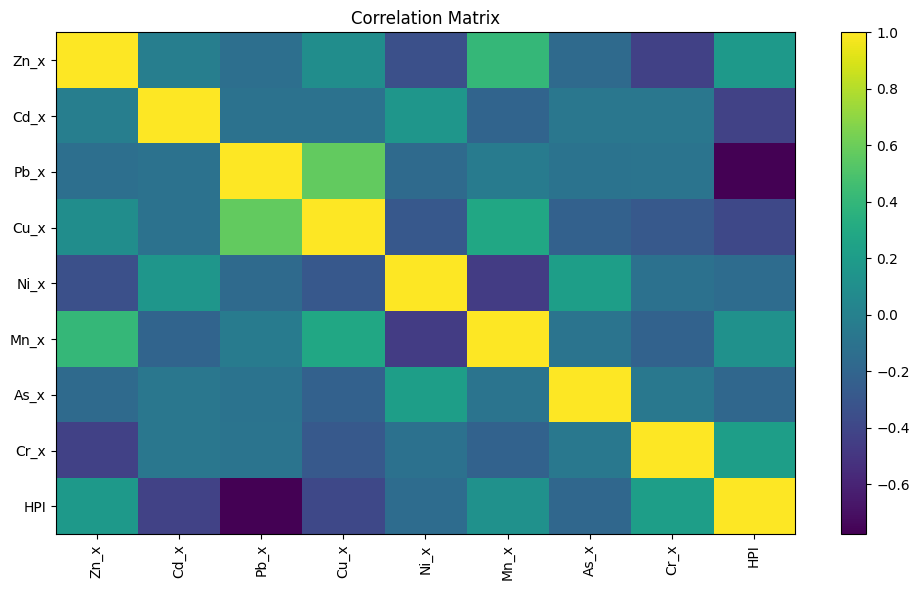

In [94]:
plt.figure(figsize=(10, 6))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [95]:
features = metal_columns

X = df[features]

y = df["HPI"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32, 8)
X_test shape: (8, 8)
y_train shape: (32,)
y_test shape: (8,)


In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [98]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32
Testing samples: 8


In [99]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

In [100]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 9.71445146547012e-17
RMSE: 1.3018518929051675e-16
R²  : 1.0


In [101]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

In [102]:
dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree
MAE : 0.0008706788972626112
RMSE: 0.0013273830926091605
R²  : 0.9314034354383729


In [103]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [104]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 0.0013302435318335581
RMSE: 0.00265430569876395
R²  : 0.7257089216587328


In [105]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [106]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost
MAE : 0.0013788152448613034
RMSE: 0.0024937528847050494
R²  : 0.7578878224834764


In [107]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2": [
        linear_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression  9.714451e-17  1.301852e-16  1.000000
1      Decision Tree  8.706789e-04  1.327383e-03  0.931403
2      Random Forest  1.330244e-03  2.654306e-03  0.725709
3            XGBoost  1.378815e-03  2.493753e-03  0.757888


In [108]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

  Feature  Importance
2    Pb_x    0.364573
1    Cd_x    0.274177
0    Zn_x    0.117057
6    As_x    0.096645
3    Cu_x    0.094208
4    Ni_x    0.033666
5    Mn_x    0.019256
7    Cr_x    0.000418


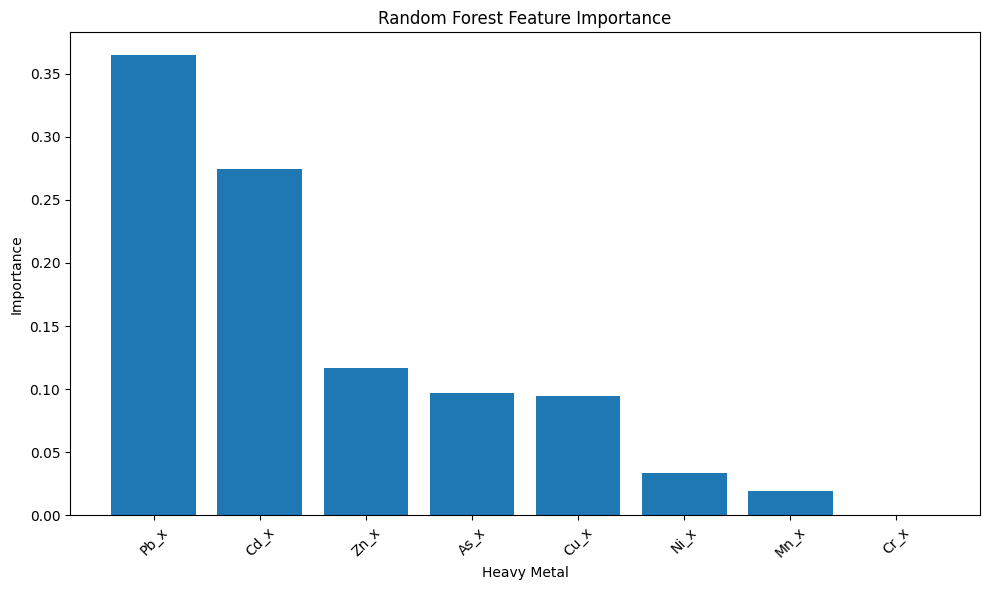

In [109]:
plt.figure(figsize=(10, 6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Heavy Metal")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

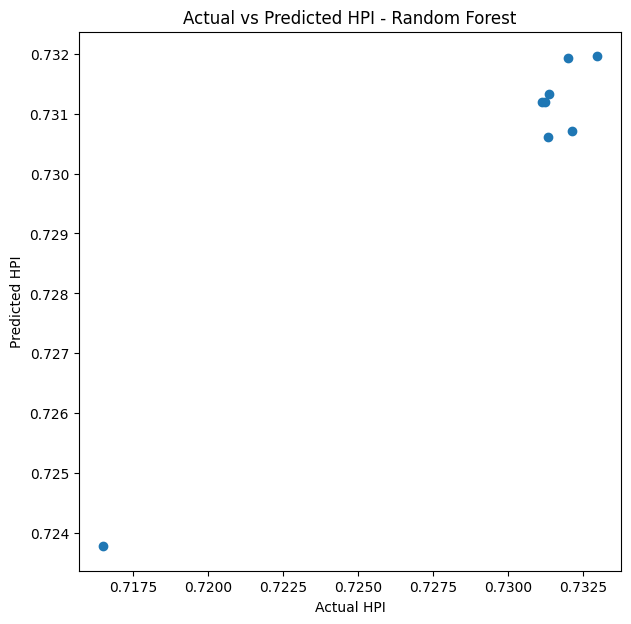

In [110]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual HPI")
plt.ylabel("Predicted HPI")

plt.title(
    "Actual vs Predicted HPI - Random Forest"
)

plt.show()

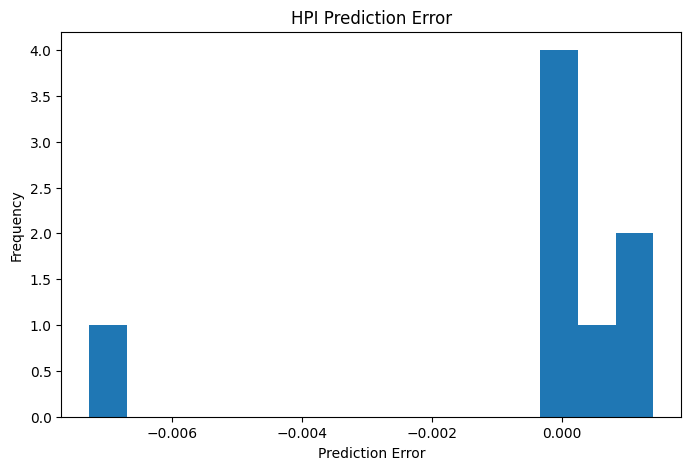

In [111]:
error = y_test - rf_pred

plt.figure(figsize=(8, 5))

plt.hist(error, bins=15)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("HPI Prediction Error")

plt.show()

In [112]:
import joblib

joblib.dump(
    rf_model,
    "heavy_metal_hpi_random_forest.pkl"
)

['heavy_metal_hpi_random_forest.pkl']

In [113]:
joblib.dump(
    features,
    "hpi_features.pkl"
)

['hpi_features.pkl']

In [114]:
model = joblib.load(
    "heavy_metal_hpi_random_forest.pkl"
)

features = joblib.load(
    "hpi_features.pkl"
)

In [115]:
new_sample = pd.DataFrame({
    "Zn_x": [0.12],
    "Cd_x": [0.003],
    "Pb_x": [0.021],
    "Cu_x": [0.03],
    "Ni_x": [0.041],
    "Mn_x": [0.10],
    "As_x": [0.015],
    "Cr_x": [0.032]
})

In [116]:
predicted_hpi = model.predict(
    new_sample
)

print("Predicted HPI:", predicted_hpi[0])

Predicted HPI: 0.7311664975757902


In [117]:
y = df["HPI"]

In [118]:
y = df["HEI"]